# Домашнє завдання до модуля «Алгоритми навчання без вчителя»
## Отримуємо дані

In [33]:
from home_works.machine_learning.util import get_desired_datasets

url = "https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl"

df = get_desired_datasets(url)['concrete']

df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31


## Створюємо нову ознаку **Components** для підрахунку кількості інгредієнтів

In [34]:
components = [c for c in df.columns if c != 'Cement']
df['Components'] = df[components].gt(0).sum(axis=1)

df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46,5
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23,5
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02,5
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19,5
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31,7


## Визначаємо, чи є пропущені значення в датасеті

In [35]:
df.isna().mean()

Cement                 0.0
BlastFurnaceSlag       0.0
FlyAsh                 0.0
Water                  0.0
Superplasticizer       0.0
CoarseAggregate        0.0
FineAggregate          0.0
CompressiveStrength    0.0
Components             0.0
dtype: float64

Аналіз показав, що нема

## Проводимо стандартизацію даних в новий датасет

In [36]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df.columns.str.strip()

scaler = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

df_scaled["Cement"] = df["Cement"]

df_scaled.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components
0,102.0,0.785676,-0.937685,0.424376,-1.249389,-0.834174,2.426039,-0.870833,-0.783621
1,108.3,0.892770,-0.937685,1.021584,-1.249389,-0.224074,1.155086,-0.628514,-0.783621
2,116.0,1.013536,-0.937685,0.424376,-1.249389,-0.562489,1.741364,-0.513461,-0.783621
3,122.6,1.137720,-0.937685,1.021584,-1.249389,0.014246,0.486810,-0.373984,-0.783621
4,132.0,1.395202,1.491447,-0.255922,-0.230502,-1.073686,-0.394658,-0.366271,1.173140


## Визначаємо оптимальну кількість кластерів для **KMeans** кластеризації через **KElbowVisualizer**

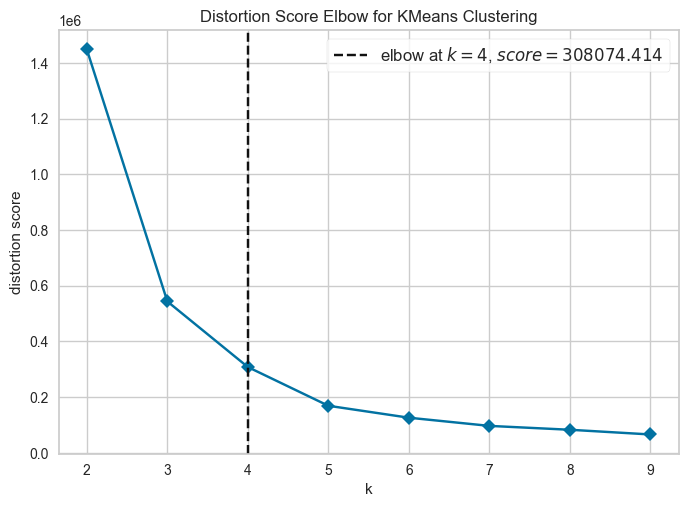

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [37]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model_kmn = KMeans(random_state=42)

visualizer = KElbowVisualizer(
       model_kmn,
        k=(2, 10),
        timings=False)

visualizer.fit(df_scaled)

visualizer.show()

In [38]:
k_best = visualizer.elbow_value_
k_best

np.int64(4)

## Тепер проводимо кластеризацію на оптимальну кількість кластерів

In [39]:
model_kmn = KMeans(n_clusters=k_best, random_state=42)

model_kmn.fit(df_scaled)

set(model_kmn.labels_)

{np.int32(0), np.int32(1), np.int32(2), np.int32(3)}

## Проводимо кластеризацію оригінальних даних навченою нами моделлю та маркуємо оригінальний датасет отриманими кластерами

In [40]:
cem_pred = model_kmn.predict(df)

df["Cluster"] = cem_pred

df.head(20)

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components,Cluster
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46,5,2
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23,5,2
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02,5,2
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19,5,2
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31,7,2
5,132.0,207.0,161.0,179.0,5.0,867.0,736.0,33.30,7,2
6,133.0,200.0,0.0,192.0,0.0,927.4,839.2,36.59,5,2
7,133.0,210.0,0.0,196.0,3.0,949.0,795.0,31.03,6,2
8,133.1,210.2,0.0,195.7,3.1,949.4,795.3,28.94,6,2
9,134.7,0.0,165.7,180.2,10.0,961.0,804.9,13.29,6,2


## Проводимо аналіз отриманої кластеризації
### Підраховуємо кількість експериментів в кожному кластері

In [41]:
df.groupby("Cluster").count()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components
Cluster,,,,,,,,,
0,121,121,121,121,121,121,121,121,121
1,38,38,38,38,38,38,38,38,38
2,152,152,152,152,152,152,152,152,152
3,116,116,116,116,116,116,116,116,116


### Виводимо мінімум, максимум та медіану для кожної ознаки в кластеризованих даних

In [42]:
df.groupby("Cluster").agg(['min', 'median', 'max'])

Cement                BlastFurnaceSlag               FlyAsh         \
           min  median    max              min median    max    min median   
Cluster                                                                      
0        203.5  260.00  298.2              0.0   15.0  359.4    0.0   81.8   
1        424.0  482.50  540.0              0.0    0.0  177.0    0.0    0.0   
2        102.0  153.35  202.0              0.0  145.0  290.2    0.0  118.8   
3        299.8  331.00  405.0              0.0    0.0  282.8    0.0    0.0   

                Water  ... CoarseAggregate FineAggregate                 \
           max    min  ...             max           min  median    max   
Cluster                ...                                                
0        174.7  140.8  ...          1119.0         594.0  774.00  945.0   
1        132.0  137.8  ...          1125.0         594.0  715.95  896.0   
2        200.1  121.8  ...          1145.0         612.0  780.00  943.1   
3        163.0  126.6  ...          1134.3         594.0  765.50  992.6   

        CompressiveStrength                Components             
                        min  median    max        min median max  
Cluster                                                           
0                     11.47  40.710  76.80          4    6.0   7  
1                     23.85  60.675  79.99          4    5.0   7  
2                      8.54  29.030  56.81          4    6.0   7  
3                      9.87  41.050  82.60          4    6.0   7  

[4 rows x 27 columns]

### Виводимо візуалізацію оригінальних даних за знайденими кластерами

In [56]:
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


def show_clusters(data: pd.DataFrame, km_label: str):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    plot_df = pd.DataFrame(PCA(n_components=3).fit_transform(data), columns=["pc1", "pc2", "pc3"])

    scatter = ax.scatter(
        plot_df["pc1"],
        plot_df["pc2"],
        plot_df["pc3"],
        c=data[km_label],    # колір за кластерами
        cmap="tab10",
        s=50
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.title("K-means clusters (3D)")

    plt.show()

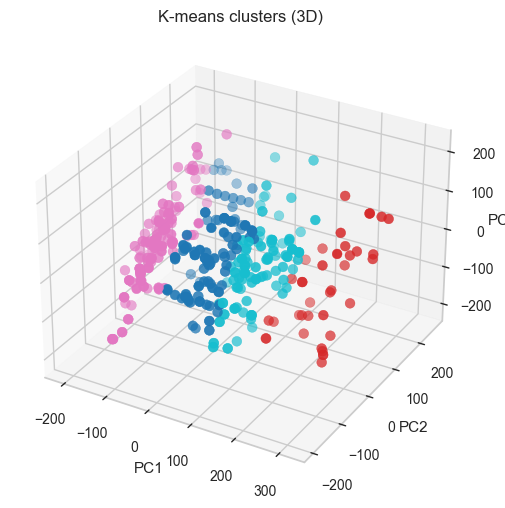

In [58]:
show_clusters(df, "Cluster")

## Висновки
У цьому домашньому завданні ми:
- Завантаження датасету
- Створення ознаки, котра підраховує кількість компонентів в рецепті певного виду цементу
- Провели автоматичне визначення оптимальної кількості кластерів
- Провели кластеризацію за алгоритмом **KMeans** на оптимальну кількість кластерів
- Провели попередній аналіз отриманих кластерів
Результат виглядає достатньо оптимістично, якщо поглянути на 3D візуалізацію. Саме таку розмірність я обрав для того, щоб наблизити деталізацію ближче до оригінальної вимірності. Тут ми бачимо, що знайдені нами кластери майже не перетинаються та дійсно обʼєднують споріднені дані.